<a href="https://colab.research.google.com/github/VioletLiu0620/deeplearning/blob/main/notes/02_neural_network_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network Classification with PyTorch

Classification is a problem of predicitng whether something is one thing or another (there can be mutiple things as options)

## 1. Make classification data and get it ready

In [ ]:
import sklearn
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

In [ ]:
len(X), len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X:\n {X[:5]}")
print(f"First 5 samples of y:\n {y[:5]}")

First 5 samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y:
 [1 1 1 1 0]


In [ ]:
# Make DataFrame of circle data
import pandas as pd

# Using a dictionary
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "labels": y})
circles.head(10)

,X1,X2,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


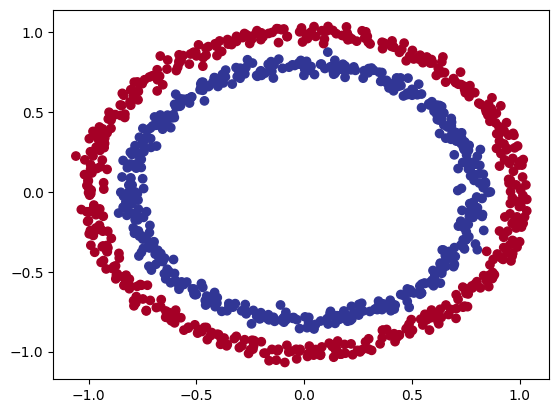

In [ ]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(x= X[:, 0],
            y= X[:, 1],
            c= y,
            cmap= plt.cm.RdYlBu)

**Note**: the data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### 1.1 Check input and output shapes

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features an dlabels
X_sample = X[0]
y_sample = y[0]

print(f"Vlaues for one sample of X: {X_sample}, and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape}, and the same for y: {y_sample.shape}")

Vlaues for one sample of X: [0.75424625 0.23148074], and the same for y: 1
Shapes for one sample of X: (2,), and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [ ]:
import torch

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [ ]:
# Split data into training and test data
from sklearn.model_selection import train_test_split

# This order is fixied with the train_test_split()
X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size = 0.2, # 0.2 = 20% of the data will be tested, vice versa
                                                   random_state=42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Let's build a model to calssify out blue and red dots.

To do so, we want to:
1. Setup device agonistic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss fucntion and optimizer
4. Create a training and test loop

In [ ]:
# import PyTorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've setup device agonistic code, let's create a model that:

1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target `device`

In [ ]:
X_train.shape

torch.Size([800, 2])

In [ ]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    # 2. Create 2 nn.Linear layers capable of handling the shape of our data
    self.layer_1 = nn.Linear(in_features=2, out_features=5) # take in 2 features and upscales to 5 features
    self.layer_2 = nn.Linear(in_features=5, out_features=1) # take in 5 features from previous layer and output a single feature (same shape as y)

  # 3. Define a forward() method that outlines the forward pass
  def forward(self, x):
    return self.layer_2(self.layer_1(x))

# 4. Instantiate an isntance of our model calss and send it tot hte target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
device

'cuda'

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[-0.5329, -0.6983],
                      [ 0.2034,  0.5928],
                      [-0.3098,  0.5510],
                      [-0.1756,  0.3215],
                      [ 0.5186, -0.4663]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.2347, -0.4672,  0.4879,  0.6787,  0.6281], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.1201,  0.2670, -0.1966, -0.3594,  0.3073]], device='cuda:0')),
             ('layer_2.bias', tensor([-0.2365], device='cuda:0'))])

In [ ]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Make predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of prediction: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{untrained_preds[:10]}")
print(f"\nFirst 10 labels: \n{y_test[:10]}")

Length of prediction: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.8388],
        [-0.8131],
        [-0.6365],
        [-0.8973],
        [-0.2084],
        [-0.1960],
        [-0.4630],
        [-0.3174],
        [-0.6549],
        [-0.8067]], device='cuda:0')

First 10 labels: 
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

Which loss fucntion or optimizer should you use?

again... this is problem specific.

For example, for regression, you might want MAE or MSE (mean absolute error or mean squared error).

For classfication, you might want bianry cross entrop or categorical cross entropy (cross entropy)

As a reminder, the loss fucntion measure how wrong your models predictions are.

And for optimizer, tow fo th most common and useful are SGD and Adam, however, PyTorch has many built-in options

* For the loss fucntion we're going to use `torch.nnBECwithLogitsLoss()`


In [ ]:
# Setup the loss fucntion
# loss_fn = nn.BCELoss() # BCELoss = requires inputs to have gone throught he sigmoid activation function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation funciton built-in

optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr= 0.1)

In [ ]:
# Calculate accuracy - TP + TN / TP + TN + FP + FN - out of 100 smaples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

## 3. Train Model

To train our model, we're going to need to build a training loop

set model.train~

1. Forward pass
2. Calculate the loss
3. Optimizer zero grad
4. Loss backward
5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert these **logits** into prediction probabilities by passing them to some kind of activation fucntion (e.g. sigmoid for binary classification and soft max for multicalss classification)

Then, we can convert our mode's prediction probabilities to **prediction labels** by either rounding them or taking he `argmax()`

In [ ]:
#View the first 5 outputs of the forward pass on the test data

with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.8388],
        [-0.8131],
        [-0.6365],
        [-0.8973],
        [-0.2084]], device='cuda:0')

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
# Use the sigmoid activation function on our model logits to turn them nto predcition probibilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.3018],
        [0.3072],
        [0.3460],
        [0.2896],
        [0.4481]], device='cuda:0')

For our model prediciton probability values, we need to perform. a range-style rounding on them:

* `y_preds_probs` >= 0.5, `y=1` class 1
* `y_preds_probs` < 0.5, `y=0` class 0

In [ ]:
# Find the predcited labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs using sigmoid -> pred labels using round)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check if equal
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

In [ ]:
### 3.2 Building a training loop
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculating loss and accuracy
  # loss = loss_fn(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, # Because we are using BCEWithLogitsLoss, it expects logtis as input
                 y_train)
  acc = accuracy_fn(y_true= y_train,
                    y_pred= y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward (backporpagation)
  loss.backward()

  # 5. optimizer.step
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # 2. Calculate test loss/acc
    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= test_pred)

  # Print out what's happening
  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Loss: {loss:.5f}, Acc: {acc:.2f}, Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0, Loss: 0.73684, Acc: 50.00, Test loss: 0.73001, Test acc: 50.00%
Epoch: 10, Loss: 0.70944, Acc: 41.25, Test loss: 0.70581, Test acc: 45.50%
Epoch: 20, Loss: 0.70113, Acc: 48.00, Test loss: 0.69887, Test acc: 46.00%
Epoch: 30, Loss: 0.69808, Acc: 49.38, Test loss: 0.69670, Test acc: 46.50%
Epoch: 40, Loss: 0.69664, Acc: 50.50, Test loss: 0.69593, Test acc: 46.00%
Epoch: 50, Loss: 0.69578, Acc: 50.38, Test loss: 0.69562, Test acc: 46.00%
Epoch: 60, Loss: 0.69519, Acc: 50.12, Test loss: 0.69548, Test acc: 49.00%
Epoch: 70, Loss: 0.69475, Acc: 49.62, Test loss: 0.69540, Test acc: 52.00%
Epoch: 80, Loss: 0.69442, Acc: 49.25, Test loss: 0.69536, Test acc: 51.50%
Epoch: 90, Loss: 0.69415, Acc: 49.62, Test loss: 0.69534, Test acc: 50.00%


In [ ]:
y_train.shape

torch.Size([800])

## 4. Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything...

So to inspect it let's make some prediction and make them visual!

To do so, we're going to import a function called `plot_decision_boundary()`

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo (if it's not already downloaded)

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Download helper_fucntions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

  from helper_functions import plot_predictions, plot_decision_boundary

Download helper_fucntions.py


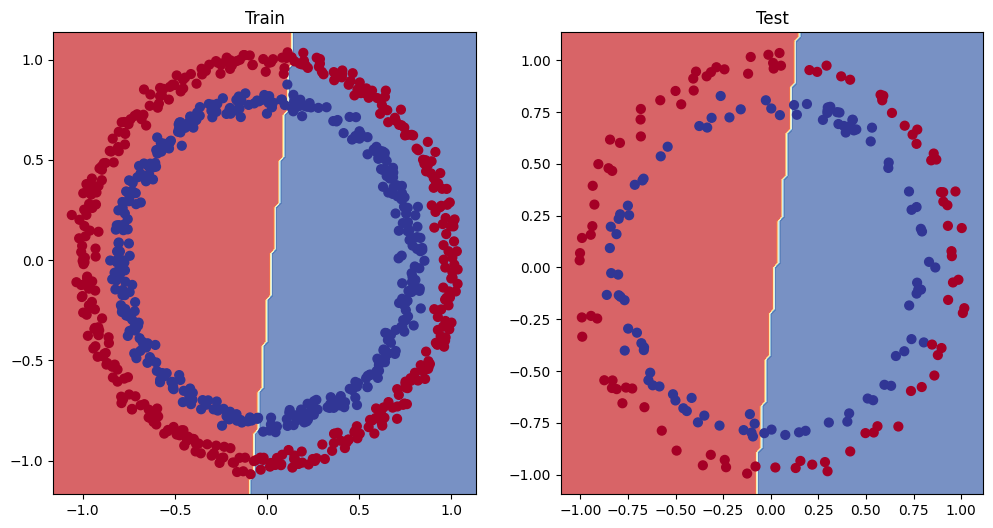

In [ ]:
# Plot decision boudnary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Improving a model (from a model perspective)

- Add more layers - give the model more cahnces to learn about patterns in hte data
- Add more hidden units - go from 5 hidden units to 10 hidden units
- Fit for longer
- Changing the activation functions
- Change the loss function

These options are all from a model's persepctive because they deal directly with the model, not the data.

And because these options are all values we can change called **hyperparameters**.

Let's try and improve our model by:
- adding more hidden units
- increase the number of layers: 2->3
- increase the number of epochs: 100->1000

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984], device='cuda:0')),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.122

In [ ]:
# Create a loss function
loss_fn_1 = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer_1 = torch.optim.SGD(params= model_1.parameters(),
                              lr= 0.1)

In [ ]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Training longer
epochs = 1000

# Put data on the target device
X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_1.train()

  # Forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # sigmoid help cahnge logits into pred probabilities and then to prediction using round

  # Calculate the loss
  loss = loss_fn_1(y_logits, y_train)
  acc = accuracy_fn(y_true= y_train,
                 y_pred= y_pred)

  # optimizer zero grad
  optimizer_1.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step
  optimizer_1.step()

  ### Testing
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Calculate the loss
    test_loss = loss_fn_1(test_logits, y_test)
    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= test_pred)

  if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.5f}, Acc: {acc:.2f}, Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0, Loss: 0.69396, Acc: 50.88, Test loss: 0.69261, Test acc: 51.00%
Epoch: 100, Loss: 0.69305, Acc: 50.38, Test loss: 0.69379, Test acc: 48.00%
Epoch: 200, Loss: 0.69299, Acc: 51.12, Test loss: 0.69437, Test acc: 46.00%
Epoch: 300, Loss: 0.69298, Acc: 51.62, Test loss: 0.69458, Test acc: 45.00%
Epoch: 400, Loss: 0.69298, Acc: 51.12, Test loss: 0.69465, Test acc: 46.00%
Epoch: 500, Loss: 0.69298, Acc: 51.00, Test loss: 0.69467, Test acc: 46.00%
Epoch: 600, Loss: 0.69298, Acc: 51.00, Test loss: 0.69468, Test acc: 46.00%
Epoch: 700, Loss: 0.69298, Acc: 51.00, Test loss: 0.69468, Test acc: 46.00%
Epoch: 800, Loss: 0.69298, Acc: 51.00, Test loss: 0.69468, Test acc: 46.00%
Epoch: 900, Loss: 0.69298, Acc: 51.00, Test loss: 0.69468, Test acc: 46.00%


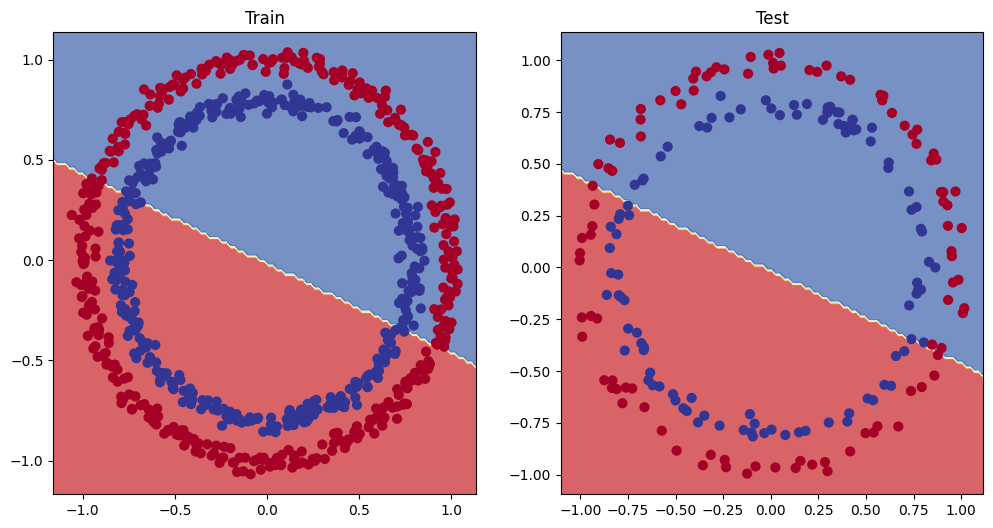

In [ ]:
# Plot decision boudnary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a strainght line

One way to troubleshoot to a larger problem is to test out a smaller problem.

In [ ]:
# Create some data
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # linear regression formula

# Check the data
print(len(X_regression))

100


In [ ]:
# Create train and test split
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression,
                                                   y_regression,
                                                   test_size = 0.2, # 0.2 = 20% of the data will be tested, vice versa
                                                   random_state=42)

In [ ]:
len(X_train_regression), len(X_test_regression)

(80, 20)

### 5.2 Adjusting `model_1` to fit a straight line

In [ ]:
X_train_regression[:5]

tensor([[0.5500],
        [0.8800],
        [0.2600],
        [0.4200],
        [0.6900]])

In [ ]:
# Same architecture as model_1 but using nn.Sequential
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss and optimzier
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)

In [ ]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number aof epochs
epochs = 1000

# Put data on the target device
X_train_regression, X_test_regression = X_train_regression.to(device), X_test_regression.to(device)
y_train_regression, y_test_regression = y_train_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):

  model_2.train()

  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ## Testing
  model_2.eval()
  test = model_2(X_test_regression)
  test_loss = loss_fn(test, y_test_regression)

  if epoch % 100 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.5f}, Test loss: {test_loss:.5f}")


Epoch: 0, Loss: 0.80353, Test loss: 0.73955
Epoch: 100, Loss: 0.02930, Test loss: 0.01250
Epoch: 200, Loss: 0.02530, Test loss: 0.01574
Epoch: 300, Loss: 0.02403, Test loss: 0.01600
Epoch: 400, Loss: 0.02399, Test loss: 0.01505
Epoch: 500, Loss: 0.02319, Test loss: 0.01497
Epoch: 600, Loss: 0.02219, Test loss: 0.01511
Epoch: 700, Loss: 0.02139, Test loss: 0.01442
Epoch: 800, Loss: 0.02143, Test loss: 0.01428
Epoch: 900, Loss: 0.02098, Test loss: 0.01401


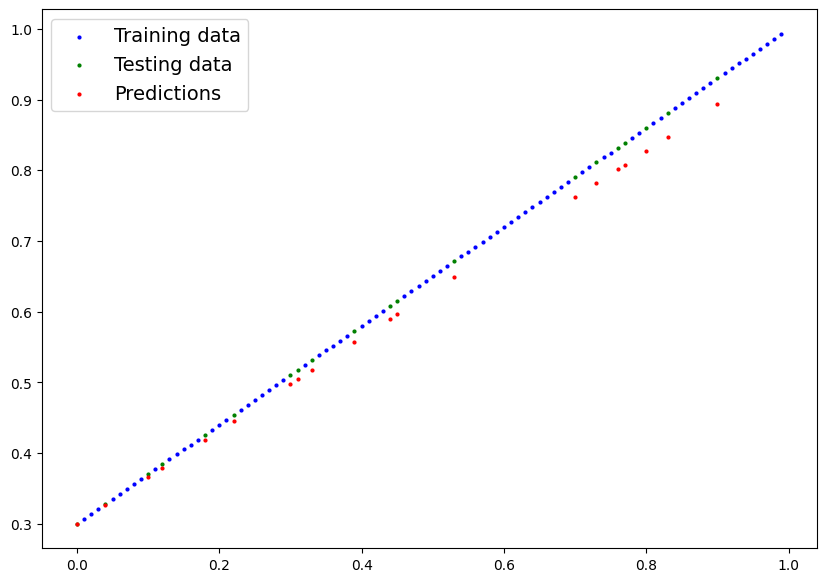

In [ ]:
# Turn on evaluation mode
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())

 ## 6. The missing piece: non-linearity

 "What patterns could you draw if you were given an infinte amount of a straight and non-straight lines?"

 Or in machine learning terms, in infinte (but really it is finite) of linear and non-linear fucntions?



### 6.1 Recreating non-linear data (red and blue circles)

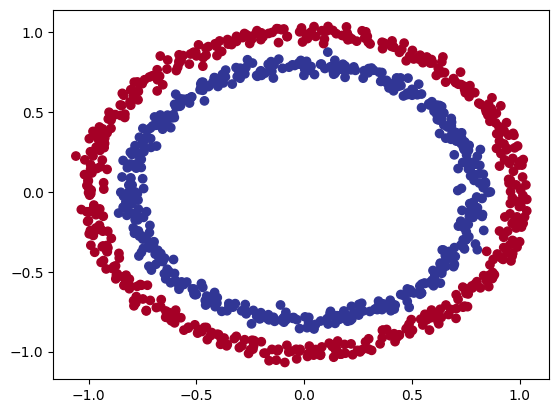

In [ ]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)

plt.scatter(X[:,0], X[:, 1], c=y, cmap= plt.cm.RdYlBu )

In [ ]:
# Convert data to tnesors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

In [ ]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Builidng a model with non-linearity

* Linear = straight linear
* Non-linear = non-straight lines

Artificial neural networs are a large combinations of linear and non-linear fucntions which are potentially able to find patterns in data.

In [ ]:
# Build a model with non-linear activation functions
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU() # if the input is negative = 0, else output = input
    # relu is a non-linear activation function

  def forward(self, x):
    # Where should we put our non linear activation functions?
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
next(model_3.parameters()).device

device(type='cuda', index=0)

In [ ]:
# Loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

In [ ]:
### Train and testing loop
torch.cuda.manual_seed(42)


epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
  ### Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # 2. Calculate the loss
  loss = loss_fn(y_logits,
                 y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  ### Testing
  model_3.eval()

  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)

    test_acc = accuracy_fn(y_true= y_test,
                           y_pred= test_pred)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch}, Loss: {loss:.5f}, Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}")


Epoch: 0, Loss: 0.69295, Test Loss: 0.69319, Test Acc: 50.00
Epoch: 100, Loss: 0.69115, Test Loss: 0.69102, Test Acc: 52.50
Epoch: 200, Loss: 0.68977, Test Loss: 0.68940, Test Acc: 55.00
Epoch: 300, Loss: 0.68795, Test Loss: 0.68723, Test Acc: 56.00
Epoch: 400, Loss: 0.68517, Test Loss: 0.68411, Test Acc: 56.50
Epoch: 500, Loss: 0.68102, Test Loss: 0.67941, Test Acc: 56.50
Epoch: 600, Loss: 0.67515, Test Loss: 0.67285, Test Acc: 56.00
Epoch: 700, Loss: 0.66659, Test Loss: 0.66322, Test Acc: 59.00
Epoch: 800, Loss: 0.65160, Test Loss: 0.64757, Test Acc: 67.50
Epoch: 900, Loss: 0.62362, Test Loss: 0.62145, Test Acc: 79.00


### 6.4 Evaluating a model trained with non-linear activation functions

In [ ]:
# Make predictions
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

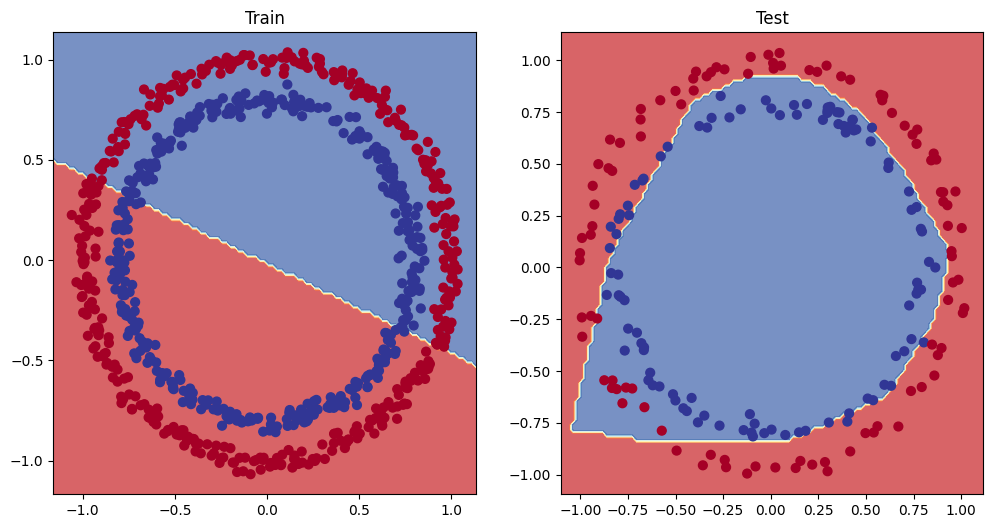

In [ ]:
# Plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # linearity
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # non_linearity

## 7. Replicating non-linear activation functions

Neural networks, rather than us telling the model what to learn, we give it the tools to discover paterns in data and it tries to figure out the patterns on its own.

And these tools are linear and non-linear functions.

In [ ]:
# Create a tensor to start with
A = torch.arange(-10, 10, 1, dtype= torch.float32)

In [ ]:
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

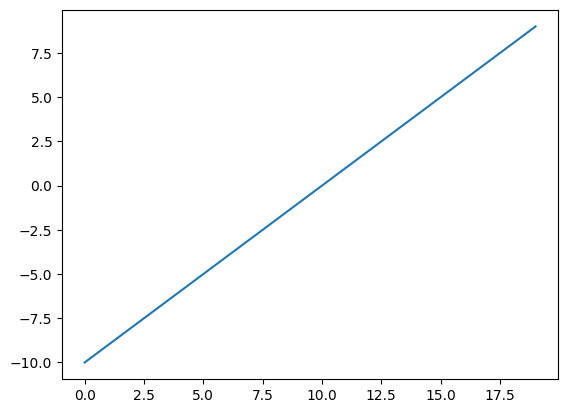

In [ ]:
# Visualize the tensor
plt.plot(A)

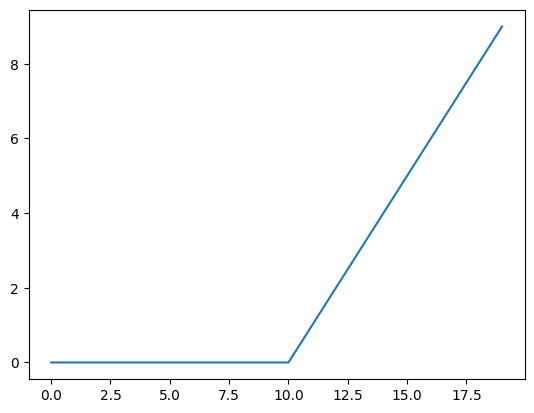

In [ ]:
plt.plot(torch.relu(A))

In [ ]:
def relu(x: torch.Tensor) -> torch.Tensor:
  return torch.maximum(torch.tensor(0), x)
# Compare 0 every single item in x
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

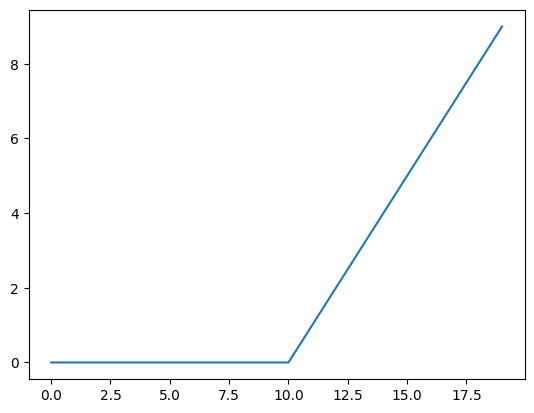

In [ ]:
plt.plot(relu(A))

In [ ]:
def sigmoid(x):
  return 1 / (1+torch.exp(-x))

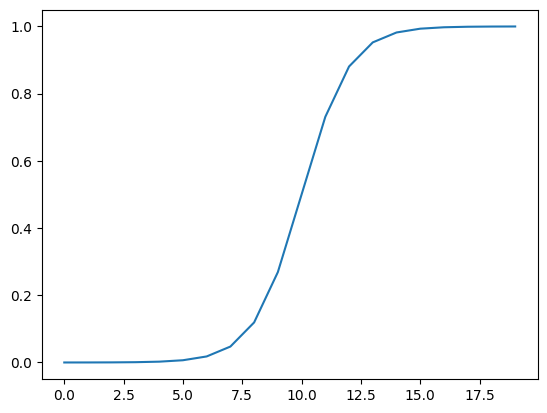

In [ ]:
plt.plot(sigmoid(A))


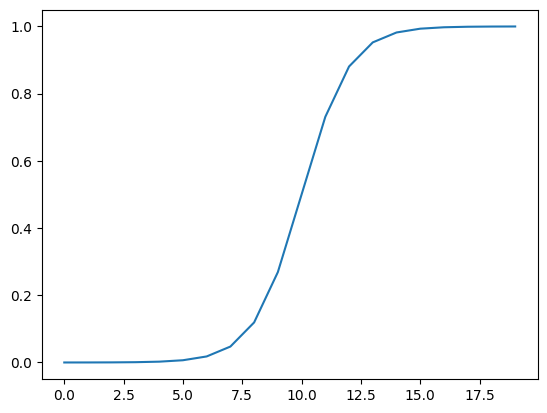

In [ ]:
plt.plot(torch.sigmoid(A))

## 8. Putting it all together with a multi-class classification problem

- Binary Classification = one thing or another (cat vs. dog)
- Multi-class classification = more than one things or another (cat vs. dog vs. chicken)

### 8.1 Creating a toy multi-class dataset

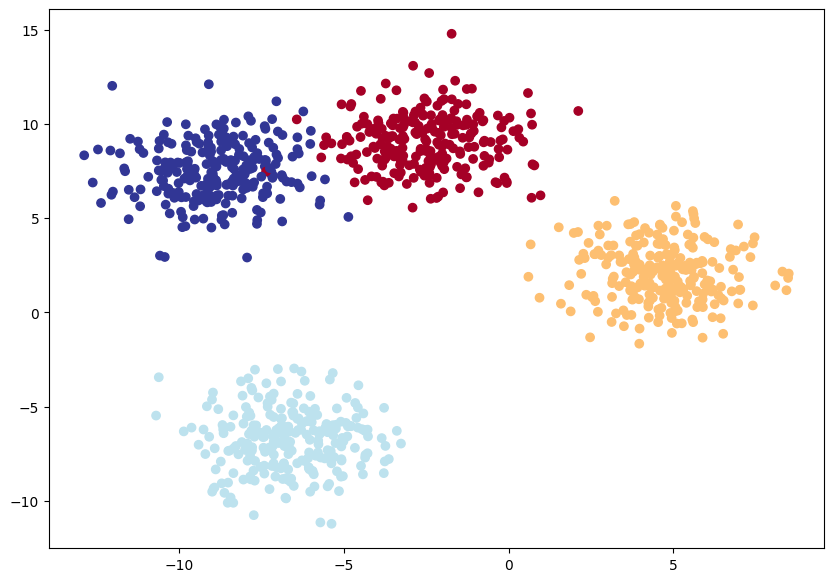

In [ ]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples    = 1000,
                            n_features   = NUM_FEATURES,
                            centers      = NUM_CLASSES,
                            cluster_std  = 1.5,
                            random_state = 42)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size =0.2,
                                                                        random_state =42)

# 4. Plot the data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0], X_blob[:, 1], c=y_blob, cmap= plt.cm.RdYlBu)

### 8.2 Building a multi-class classification model in PyTorch

In [ ]:
# Create device agnoistic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """ Initializes multi-class classification model.

    Args:
      input_features (int): Number of input features to the model
      output_features (int): Number of output features (number of output classes)
      hidden_units (int): Number of hidden units between layers, default 8

    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features = hidden_units),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.Linear(in_features= hidden_units, out_features= output_features)
        )
  def forward(self, x):
    return self.linear_layer_stack(x)

# Create the model and send to the target device
model_4 = BlobModel(input_features= NUM_FEATURES,
                    output_features= NUM_CLASSES,
                    hidden_units=8).to(device)

model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In [ ]:
# Loss function
loss_fn = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.01) # learning rate is a hyperparameter you can change

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In order to evaluate and train and test our model, we need to convert our model's outputs (logits) to prediction probabilities and then to prediction labels.

- Logits -> prediction probabilities (use activation functions like sigmoid, softmax, ReLU)
- Predicition probabilities -> labels (use something like round)

In [ ]:
# Raw outputs of our model, with the inital random weights and bias
model_4.eval()
with torch.inference_mode():
  y_logits =(model_4(X_blob_test.to(device))[:5])

In [ ]:
y_blob_test.to(device)[:5]

tensor([1., 3., 2., 1., 0.], device='cuda:0')

In [ ]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])
y_logits.dtype

tensor([[-1.0943,  0.4862, -0.3858,  0.9402],
        [ 0.4370,  2.1385,  3.0942,  1.2537],
        [ 0.9735, -0.4166, -0.0660, -1.4409],
        [-0.7948,  0.0490, -0.7677,  0.3211],
        [-0.7592,  1.8848,  1.8249,  1.9368]], device='cuda:0')
tensor([[0.0644, 0.3126, 0.1307, 0.4923],
        [0.0435, 0.2383, 0.6198, 0.0984],
        [0.5910, 0.1472, 0.2090, 0.0528],
        [0.1351, 0.3140, 0.1388, 0.4122],
        [0.0232, 0.3261, 0.3072, 0.3435]], device='cuda:0')


torch.float32

In [ ]:
torch.sum(y_pred_probs[0])

tensor(1.0000, device='cuda:0')

In [ ]:
torch.argmax(y_pred_probs[0])

tensor(3, device='cuda:0')

In [ ]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([3, 2, 0, 3, 3], device='cuda:0')

In [ ]:
y_blob_train.dtype

torch.float32

### 8.5 Creating a training loop and testing loop for a multiclass pytorch model

In [ ]:
torch.cuda.manual_seed(42)

epochs = 100

X_blob_train, X_blob_test = X_blob_train.to(device), X_blob_test.to(device)
y_blob_train, y_blob_test = y_blob_train.to(device).long(), y_blob_test.to(device).long()

for epoch in range(epochs):
  # Training
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits,
                 y_blob_train)

  acc = accuracy_fn(y_true= y_blob_train,
                    y_pred= y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits,
                        y_blob_test)

    test_acc = accuracy_fn(y_true= y_blob_test,
                           y_pred= test_pred)
  if epoch % 10 == 0:
    print(f"Epoch: {epoch}, Train Loss: {loss:.5f}, Train Acc: {acc:.2f}, Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0, Train Loss: 0.91839, Train Acc: 53.75, Test Loss: 0.85855, Test acc: 55.00
Epoch: 10, Train Loss: 0.59385, Train Acc: 96.25, Test Loss: 0.56370, Test acc: 98.50
Epoch: 20, Train Loss: 0.45272, Train Acc: 97.38, Test Loss: 0.43313, Test acc: 98.50
Epoch: 30, Train Loss: 0.36906, Train Acc: 98.25, Test Loss: 0.35505, Test acc: 98.50
Epoch: 40, Train Loss: 0.31150, Train Acc: 98.88, Test Loss: 0.30082, Test acc: 99.00
Epoch: 50, Train Loss: 0.26879, Train Acc: 98.88, Test Loss: 0.26020, Test acc: 98.50
Epoch: 60, Train Loss: 0.23578, Train Acc: 99.00, Test Loss: 0.22852, Test acc: 98.50
Epoch: 70, Train Loss: 0.20960, Train Acc: 99.12, Test Loss: 0.20317, Test acc: 98.50
Epoch: 80, Train Loss: 0.18843, Train Acc: 99.12, Test Loss: 0.18250, Test acc: 98.50
Epoch: 90, Train Loss: 0.17104, Train Acc: 99.12, Test Loss: 0.16540, Test acc: 98.50


In [ ]:
# Plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # linearity
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # non_linearity

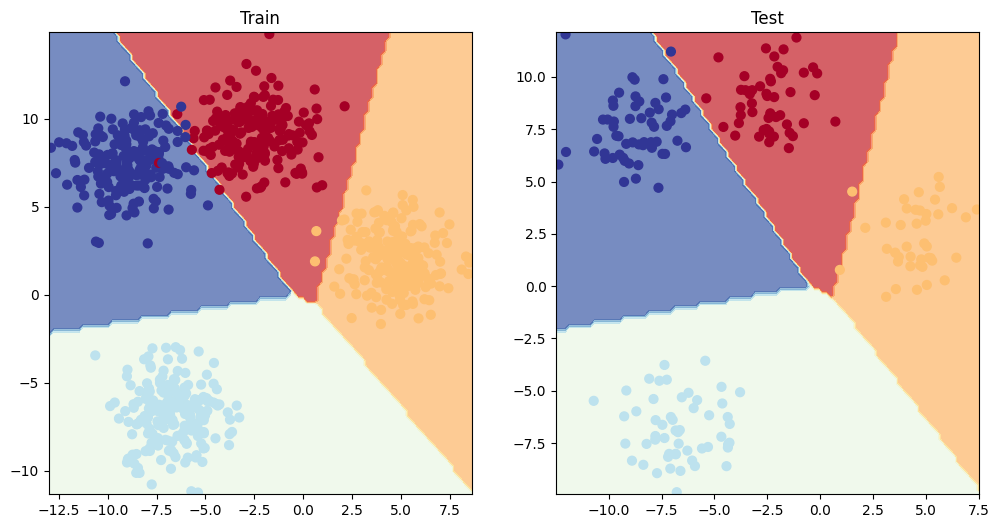

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [ ]:
# Predictions
model_4.eval()
with torch.inference_mode():
  eval_logits = model_4(X_blob_test.cpu())
  eval_preds = torch.softmax(eval_logits, dim=1).argmax(dim=1)

eval_preds[:10], y_blob_train[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0], device='cuda:0'))

## 9. A few more classification metrics...(to evaluate our classification model)

- Accuracy - out of 100 samples, how many did out model get right
- Precision - When false positive is costly, increase precision, ex: a noraml transaction is label as spam, thus freeze the account
- Recall - When false negative is costly, increase recall, ex: medical tumor detection
- F1-score - a combination of recall and precision
- Confusion Matrix - a 2x2 matrix with TP, TN, FP, FN (predicted, label)
- Classification Report - get all metric above with average and weighted

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.9 MB/s eta 0:00:00


In [ ]:
from torchmetrics import Accuracy

# Setup metric
torchmetric_accuracy = torchmetric_accuracy = Accuracy(task="multiclass", num_classes=4)


# Calculate accuracy
torchmetric_accuracy(eval_preds.cpu(), y_blob_test.cpu())

tensor(0.9900)